# Дообучение RuBERT-tiny2

Модель получает условие кейса и решение одной последовательностью и одновременно предсказывает пять оценок. Сравниваются обучение только выходного слоя, разморозка последнего слоя encoder и полное дообучение.

In [1]:
from pathlib import Path
import copy
import json
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, DataCollatorWithPadding, get_linear_schedule_with_warmup

SEED = 1537
MODEL_NAME = 'cointegrated/rubert-tiny2'
MAX_LENGTH = 512
BATCH_SIZE = 4
BAD_THRESHOLD = 60.0
Y_cols = ['score_factchecking', 'score_originality', 'score_effectiveness', 'score_logic', 'score_completeness']
TOTAL_SCORE_WEIGHTS = {'score_factchecking': 0.20, 'score_originality': 0.25, 'score_effectiveness': 0.25, 'score_logic': 0.15, 'score_completeness': 0.15}
TOTAL_WEIGHT_VECTOR = np.array([TOTAL_SCORE_WEIGHTS[column] for column in Y_cols])
DATA_DIR = Path('data/solution_evaluation/model')
ARTIFACTS_DIR = Path('../artifacts')
TRANSFORMER_DIR = ARTIFACTS_DIR / 'rubert_tiny2_multitask'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE

device(type='cpu')

## Загрузка данных

In [ ]:
train = pd.read_csv(DATA_DIR / 'train_real_synthetic.csv')
val_real = pd.read_csv(DATA_DIR / 'val_real.csv')
stress_val = pd.read_csv(DATA_DIR / 'stress_val.csv')
test_real = pd.read_csv(DATA_DIR / 'test_real.csv')
stress_test = pd.read_csv(DATA_DIR / 'stress_test.csv')
external_test = pd.read_csv(DATA_DIR / 'external_low_quality_test.csv')

frames = {
    'TRAIN': train, 'REAL_VAL': val_real, 'STRESS_VAL': stress_val,
    'REAL_TEST': test_real, 'STRESS_TEST': stress_test,
    'EXTERNAL_LOW_QUALITY_TEST': external_test,
}
{name: frame.shape for name, frame in frames.items()}

{'TRAIN': (453, 14),
 'REAL_VAL': (67, 12),
 'STRESS_VAL': (18, 14),
 'REAL_TEST': (62, 12),
 'STRESS_TEST': (42, 14),
 'EXTERNAL_LOW_QUALITY_TEST': (30, 17)}

## Подготовка текста и модель

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
assert tokenizer.model_max_length >= MAX_LENGTH

class CaseSolutionDataset(Dataset):
    def __init__(self, frame, tokenizer, max_length, training=False):
        frame = frame.reset_index(drop=True)
        self.encodings = tokenizer(
            frame['case_text'].fillna('').astype(str).tolist(),
            frame['solution_text'].fillna('').astype(str).tolist(),
            truncation='longest_first', max_length=max_length, padding=False,
        )
        self.labels = frame[Y_cols].to_numpy(dtype='float32') / 100.0
        self.sample_weights = np.where(
            training & frame.get('origin', pd.Series('', index=frame.index)).eq('real'), 2.0, 1.0
        ).astype('float32')

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        encoded = {key: values[index] for key, values in self.encodings.items()}
        encoded['labels'] = self.labels[index].tolist()
        encoded['sample_weight'] = float(self.sample_weights[index])
        return encoded


class RuBertMultiTaskRegressor(nn.Module):
    def __init__(self, model_name, output_count):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.2)
        self.regression_head = nn.Linear(self.encoder.config.hidden_size, output_count)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        encoder_output = self.encoder(
            input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids,
        )
        pooled = encoder_output.last_hidden_state[:, 0]
        return torch.sigmoid(self.regression_head(self.dropout(pooled)))

In [4]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors='pt')
datasets = {
    name: CaseSolutionDataset(frame, tokenizer, MAX_LENGTH, training=name == 'TRAIN')
    for name, frame in frames.items()
}
loaders = {
    name: DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=name == 'TRAIN',
        collate_fn=data_collator, num_workers=0, pin_memory=torch.cuda.is_available(),
    )
    for name, dataset in datasets.items()
}
{name: len(loader) for name, loader in loaders.items()}

{'TRAIN': 114,
 'REAL_VAL': 17,
 'STRESS_VAL': 5,
 'REAL_TEST': 16,
 'STRESS_TEST': 11,
 'EXTERNAL_LOW_QUALITY_TEST': 8}

## Режимы обучения

В режиме FROZEN обучается только выходной слой. PARTIAL дополнительно обучает последний слой RuBERT, FULL - всю модель. Для каждого режима сохраняется эпоха с лучшим результатом на validation.

In [5]:
MODE_CONFIGS = {
    'FROZEN': {'epochs': 8, 'encoder_lr': 0.0, 'head_lr': 1e-3},
    'PARTIAL': {'epochs': 5, 'encoder_lr': 2e-5, 'head_lr': 3e-4},
    'FULL': {'epochs': 5, 'encoder_lr': 1e-5, 'head_lr': 2e-4},
}
EARLY_STOPPING_PATIENCE = 2
EARLY_STOPPING_MIN_DELTA = 0.01
mode_best_states = {}
mode_best_scores = {}
training_history_rows = []
frozen_start_state = None

for mode_name, mode_config in MODE_CONFIGS.items():
    model = RuBertMultiTaskRegressor(MODEL_NAME, len(Y_cols)).to(DEVICE)
    if mode_name != 'FROZEN':
        model.load_state_dict(frozen_start_state)

    for parameter in model.encoder.parameters():
        parameter.requires_grad = False
    if mode_name == 'PARTIAL':
        for parameter in model.encoder.encoder.layer[-1].parameters():
            parameter.requires_grad = True
    if mode_name == 'FULL':
        for parameter in model.encoder.parameters():
            parameter.requires_grad = True

    optimizer_groups = [{'params': model.regression_head.parameters(), 'lr': mode_config['head_lr']}]
    encoder_parameters = [parameter for parameter in model.encoder.parameters() if parameter.requires_grad]
    if encoder_parameters:
        optimizer_groups.append({'params': encoder_parameters, 'lr': mode_config['encoder_lr']})
    optimizer = torch.optim.AdamW(optimizer_groups, weight_decay=0.01)
    total_steps = mode_config['epochs'] * len(loaders['TRAIN'])
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * 0.1), total_steps)
    best_selection_score = np.inf
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, mode_config['epochs'] + 1):
        model.train()
        if mode_name == 'FROZEN':
            model.encoder.eval()
        train_losses = []
        for batch in tqdm(loaders['TRAIN'], desc=f'{mode_name} epoch {epoch}', leave=False):
            labels = batch.pop('labels').to(DEVICE).float()
            sample_weight = batch.pop('sample_weight').to(DEVICE).float()
            inputs = {key: value.to(DEVICE) for key, value in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            predictions = model(**inputs)
            sample_losses = nn.functional.smooth_l1_loss(predictions, labels, reduction='none').mean(dim=1)
            loss = (sample_losses * sample_weight).sum() / sample_weight.sum()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_losses.append(loss.item())

        validation_results = {}
        model.eval()
        for dataset_name in ['REAL_VAL', 'STRESS_VAL']:
            prediction_batches = []
            label_batches = []
            with torch.no_grad():
                for batch in loaders[dataset_name]:
                    labels = batch.pop('labels').numpy() * 100.0
                    batch.pop('sample_weight')
                    inputs = {key: value.to(DEVICE) for key, value in batch.items()}
                    prediction_batches.append(model(**inputs).cpu().numpy() * 100.0)
                    label_batches.append(labels)
            dataset_predictions = np.vstack(prediction_batches)
            dataset_targets = np.vstack(label_batches)
            predicted_total = dataset_predictions @ TOTAL_WEIGHT_VECTOR
            target_total = dataset_targets @ TOTAL_WEIGHT_VECTOR
            validation_results[dataset_name] = {
                'total_MAE': mean_absolute_error(target_total, predicted_total),
                'bad_recall': ((target_total < BAD_THRESHOLD) & (predicted_total < BAD_THRESHOLD)).sum() / (target_total < BAD_THRESHOLD).sum() if (target_total < BAD_THRESHOLD).sum() else np.nan,
            }

        selection_score = 0.6 * validation_results['REAL_VAL']['total_MAE'] + 0.4 * validation_results['STRESS_VAL']['total_MAE']
        training_history_rows.append({
            'mode': mode_name, 'epoch': epoch, 'train_loss': np.mean(train_losses),
            'real_val_MAE': validation_results['REAL_VAL']['total_MAE'],
            'stress_val_MAE': validation_results['STRESS_VAL']['total_MAE'],
            'stress_bad_recall': validation_results['STRESS_VAL']['bad_recall'],
            'selection_score': selection_score,
        })
        if selection_score < best_selection_score - EARLY_STOPPING_MIN_DELTA:
            best_selection_score = selection_score
            best_state = copy.deepcopy({key: value.detach().cpu() for key, value in model.state_dict().items()})
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            break

    mode_best_states[mode_name] = best_state
    mode_best_scores[mode_name] = best_selection_score
    if mode_name == 'FROZEN':
        frozen_start_state = best_state
    del model, optimizer, scheduler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

training_history_df = pd.DataFrame(training_history_rows).round(5)
training_history_df

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

FROZEN epoch 1:   0%|          | 0/114 [00:00<?, ?it/s]

FROZEN epoch 2:   0%|          | 0/114 [00:00<?, ?it/s]

FROZEN epoch 3:   0%|          | 0/114 [00:00<?, ?it/s]

FROZEN epoch 4:   0%|          | 0/114 [00:00<?, ?it/s]

...

FULL epoch 2:   0%|          | 0/114 [00:00<?, ?it/s]

FULL epoch 3:   0%|          | 0/114 [00:00<?, ?it/s]

FULL epoch 4:   0%|          | 0/114 [00:00<?, ?it/s]

FULL epoch 5:   0%|          | 0/114 [00:00<?, ?it/s]

,mode,epoch,train_loss,real_val_MAE,stress_val_MAE,stress_bad_recall,selection_score
0,FROZEN,1,0.01841,2.90997,14.93353,0.22222,7.71939
1,FROZEN,2,0.00981,2.82025,12.99433,0.77778,6.88988
2,FROZEN,3,0.00872,3.15078,11.91533,1.00000,6.65660
3,FROZEN,4,0.00821,3.22902,11.73838,0.77778,6.63276
4,FROZEN,5,0.00752,3.18711,11.39867,1.00000,6.47173
5,FROZEN,6,0.00730,3.51884,11.04661,1.00000,6.52995
6,FROZEN,7,0.00684,3.31848,11.04084,1.00000,6.40742
7,FROZEN,8,0.00705,3.33201,10.98959,1.00000,6.39504
8,PARTIAL,1,0.00766,3.29726,10.75014,0.88889,6.27842
9,PARTIAL,2,0.00744,4.09766,10.53351,0.77778,6.67200


## Сравнение режимов

In [6]:
mode_selection_df = (
    training_history_df.sort_values('selection_score')
    .groupby('mode', as_index=False)
    .first()
    .sort_values('selection_score')
    .reset_index(drop=True)
)
selected_mode = mode_selection_df.iloc[0]['mode']
selected_model = RuBertMultiTaskRegressor(MODEL_NAME, len(Y_cols)).to(DEVICE)
selected_model.load_state_dict(mode_best_states[selected_mode])
selected_model.eval()
mode_selection_df

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

,mode,epoch,train_loss,real_val_MAE,stress_val_MAE,stress_bad_recall,selection_score
0,PARTIAL,5,0.00664,3.43319,10.28861,1.0,6.17536
1,FULL,5,0.00577,3.54078,10.22816,1.0,6.21573
2,FROZEN,8,0.00705,3.33201,10.98959,1.0,6.39504


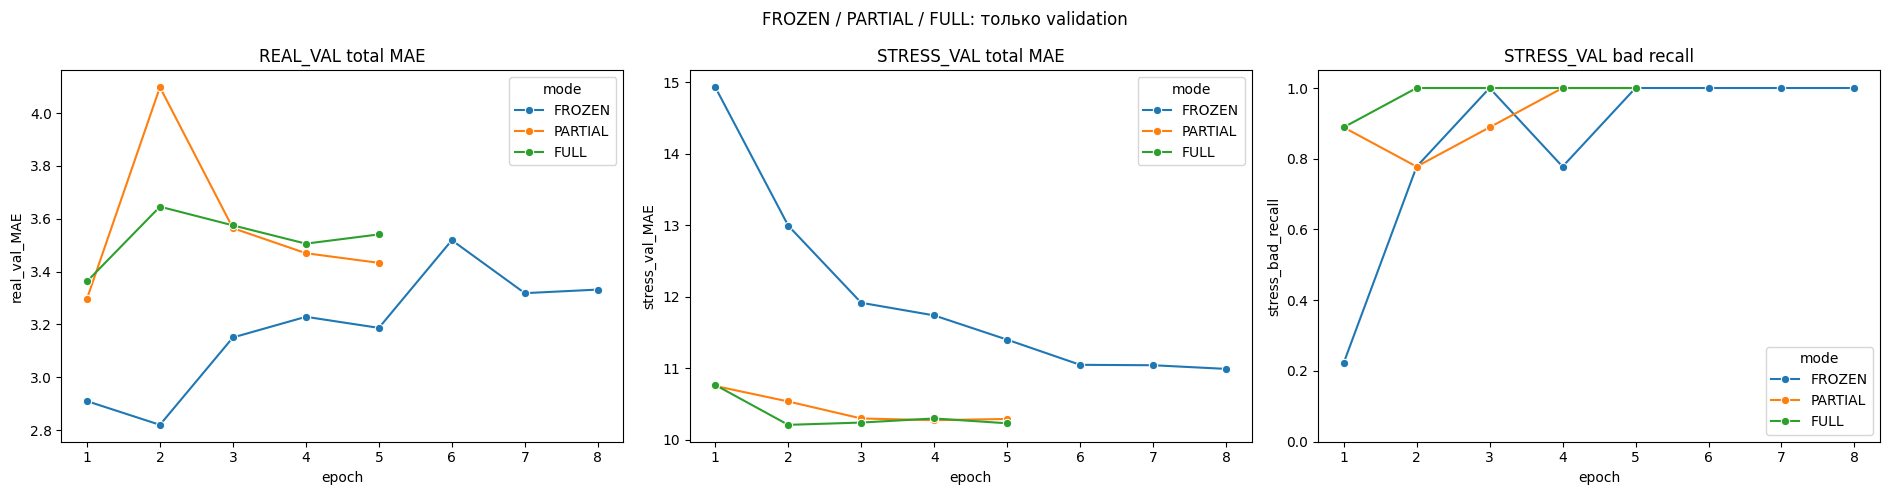

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.lineplot(data=training_history_df, x='epoch', y='real_val_MAE', hue='mode', marker='o', ax=axes[0])
axes[0].set_title('REAL_VAL total MAE')
sns.lineplot(data=training_history_df, x='epoch', y='stress_val_MAE', hue='mode', marker='o', ax=axes[1])
axes[1].set_title('STRESS_VAL total MAE')
sns.lineplot(data=training_history_df, x='epoch', y='stress_bad_recall', hue='mode', marker='o', ax=axes[2])
axes[2].set_ylim(0, 1.05)
axes[2].set_title('STRESS_VAL bad recall')
fig.suptitle('FROZEN / PARTIAL / FULL: только validation')
fig.tight_layout()
plt.show()

## Оценка выбранной модели

In [8]:
transformer_metric_rows = []
transformer_prediction_cache = {}
for dataset_name in ['REAL_TEST', 'STRESS_TEST', 'EXTERNAL_LOW_QUALITY_TEST']:
    prediction_batches = []
    label_batches = []
    with torch.no_grad():
        for batch in loaders[dataset_name]:
            labels = batch.pop('labels').numpy() * 100.0
            batch.pop('sample_weight')
            inputs = {key: value.to(DEVICE) for key, value in batch.items()}
            prediction_batches.append(selected_model(**inputs).cpu().numpy() * 100.0)
            label_batches.append(labels)
    predictions = pd.DataFrame(np.vstack(prediction_batches), columns=Y_cols)
    targets = pd.DataFrame(np.vstack(label_batches), columns=Y_cols)
    predictions['score_total'] = predictions[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    targets['score_total'] = targets[Y_cols].to_numpy() @ TOTAL_WEIGHT_VECTOR
    transformer_prediction_cache[dataset_name] = predictions
    true_bad = targets['score_total'] < BAD_THRESHOLD
    predicted_bad = predictions['score_total'] < BAD_THRESHOLD
    bad_recall = (true_bad & predicted_bad).sum() / true_bad.sum() if true_bad.sum() else np.nan
    for score in [*Y_cols, 'score_total']:
        transformer_metric_rows.append({
            'model': f'RUBERT_TINY2_{selected_mode}', 'dataset': dataset_name, 'score': score,
            'MSE': mean_squared_error(targets[score], predictions[score]),
            'MAE': mean_absolute_error(targets[score], predictions[score]),
            'R2': r2_score(targets[score], predictions[score]),
            'bad_recall': bad_recall if score == 'score_total' else np.nan,
        })
transformer_metrics_df = pd.DataFrame(transformer_metric_rows).round(4)
transformer_metrics_df

,model,dataset,score,MSE,MAE,R2,bad_recall
0,RUBERT_TINY2_PARTIAL,REAL_TEST,score_factchecking,25.3969,3.8201,-0.4697,NaN
1,RUBERT_TINY2_PARTIAL,REAL_TEST,score_originality,134.1880,10.0556,-0.4229,NaN
2,RUBERT_TINY2_PARTIAL,REAL_TEST,score_effectiveness,77.3519,7.1168,0.2766,NaN
3,RUBERT_TINY2_PARTIAL,REAL_TEST,score_logic,45.2157,5.4111,-0.7605,NaN
4,RUBERT_TINY2_PARTIAL,REAL_TEST,score_completeness,82.8589,7.6400,0.1133,NaN
5,RUBERT_TINY2_PARTIAL,REAL_TEST,score_total,17.1051,3.2893,-0.0263,NaN
6,RUBERT_TINY2_PARTIAL,STRESS_TEST,score_factchecking,616.6406,19.6815,0.3413,NaN
7,RUBERT_TINY2_PARTIAL,STRESS_TEST,score_originality,186.5483,11.1258,0.0690,NaN
8,RUBERT_TINY2_PARTIAL,STRESS_TEST,score_effectiveness,384.7621,17.1728,0.5324,NaN
9,RUBERT_TINY2_PARTIAL,STRESS_TEST,score_logic,294.6886,14.0186,0.5440,NaN


## Сохранение модели

In [9]:
TRANSFORMER_DIR.mkdir(parents=True, exist_ok=True)
tokenizer.save_pretrained(TRANSFORMER_DIR / 'tokenizer')
torch.save({
    'state_dict': mode_best_states[selected_mode],
    'model_name': MODEL_NAME, 'selected_mode': selected_mode,
    'max_length': MAX_LENGTH, 'target_columns': Y_cols,
    'total_score_weights': TOTAL_SCORE_WEIGHTS, 'bad_threshold': BAD_THRESHOLD,
    'split_seed': SEED, 'training_regime': 'ALL_SYNTH_WEIGHTED',
    'sample_weights': {'real': 2.0, 'synthetic': 1.0},
    'selection_weights': {'real': 0.6, 'stress': 0.4},
}, TRANSFORMER_DIR / 'rubert_tiny2_multitask.pt')
training_history_df.to_csv(TRANSFORMER_DIR / 'training_history.csv', index=False)
mode_selection_df.to_csv(TRANSFORMER_DIR / 'mode_selection.csv', index=False)
transformer_metrics_df.to_csv(TRANSFORMER_DIR / 'metrics.csv', index=False)

saved_checkpoint = torch.load(TRANSFORMER_DIR / 'rubert_tiny2_multitask.pt', map_location='cpu', weights_only=False)
saved_checkpoint.keys()

dict_keys(['state_dict', 'model_name', 'selected_mode', 'max_length', 'target_columns', 'total_score_weights', 'bad_threshold', 'split_seed', 'training_regime', 'sample_weights', 'selection_weights'])

## Сравнение с предыдущими моделями

In [10]:
comparison_parts = [transformer_metrics_df]
previous_metric_files = [
    ARTIFACTS_DIR / 'ridge_final_baseline_metrics.csv',
    ARTIFACTS_DIR / 'embeddings_ridge_metrics.csv',
    ARTIFACTS_DIR / 'embeddings_catboost_metrics.csv',
]
for path in previous_metric_files:
    if path.exists():
        comparison_parts.append(pd.read_csv(path))
transformer_comparison_df = pd.concat(comparison_parts, ignore_index=True)
transformer_total_comparison_df = transformer_comparison_df.loc[
    transformer_comparison_df['score'].eq('score_total'),
    ['model', 'dataset', 'MAE', 'R2', 'bad_recall'],
].sort_values(['dataset', 'MAE']).reset_index(drop=True)
transformer_total_comparison_df

,model,dataset,MAE,R2,bad_recall
0,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,EXTERNAL_LOW_QUALITY_TEST,8.5672,0.4329,0.7647
1,RUBERT_TINY2_PARTIAL,EXTERNAL_LOW_QUALITY_TEST,8.8913,0.4416,0.9412
2,RIDGE_FINAL_BASELINE,EXTERNAL_LOW_QUALITY_TEST,9.2717,0.4149,0.7059
3,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,EXTERNAL_LOW_QUALITY_TEST,9.4372,0.3724,0.8235
4,EMBEDDINGS_CATBOOST_C_SOLUTION_HANDCRAFTED,REAL_TEST,3.1610,0.1157,NaN
5,RUBERT_TINY2_PARTIAL,REAL_TEST,3.2893,-0.0263,NaN
6,RIDGE_FINAL_BASELINE,REAL_TEST,3.3863,-0.0950,NaN
7,EMBEDDINGS_RIDGE_C_SOLUTION_HANDCRAFTED,REAL_TEST,5.5908,-1.7918,NaN
8,RUBERT_TINY2_PARTIAL,STRESS_TEST,9.5991,0.5425,1.0000
9,RIDGE_FINAL_BASELINE,STRESS_TEST,10.1512,0.4486,0.9048


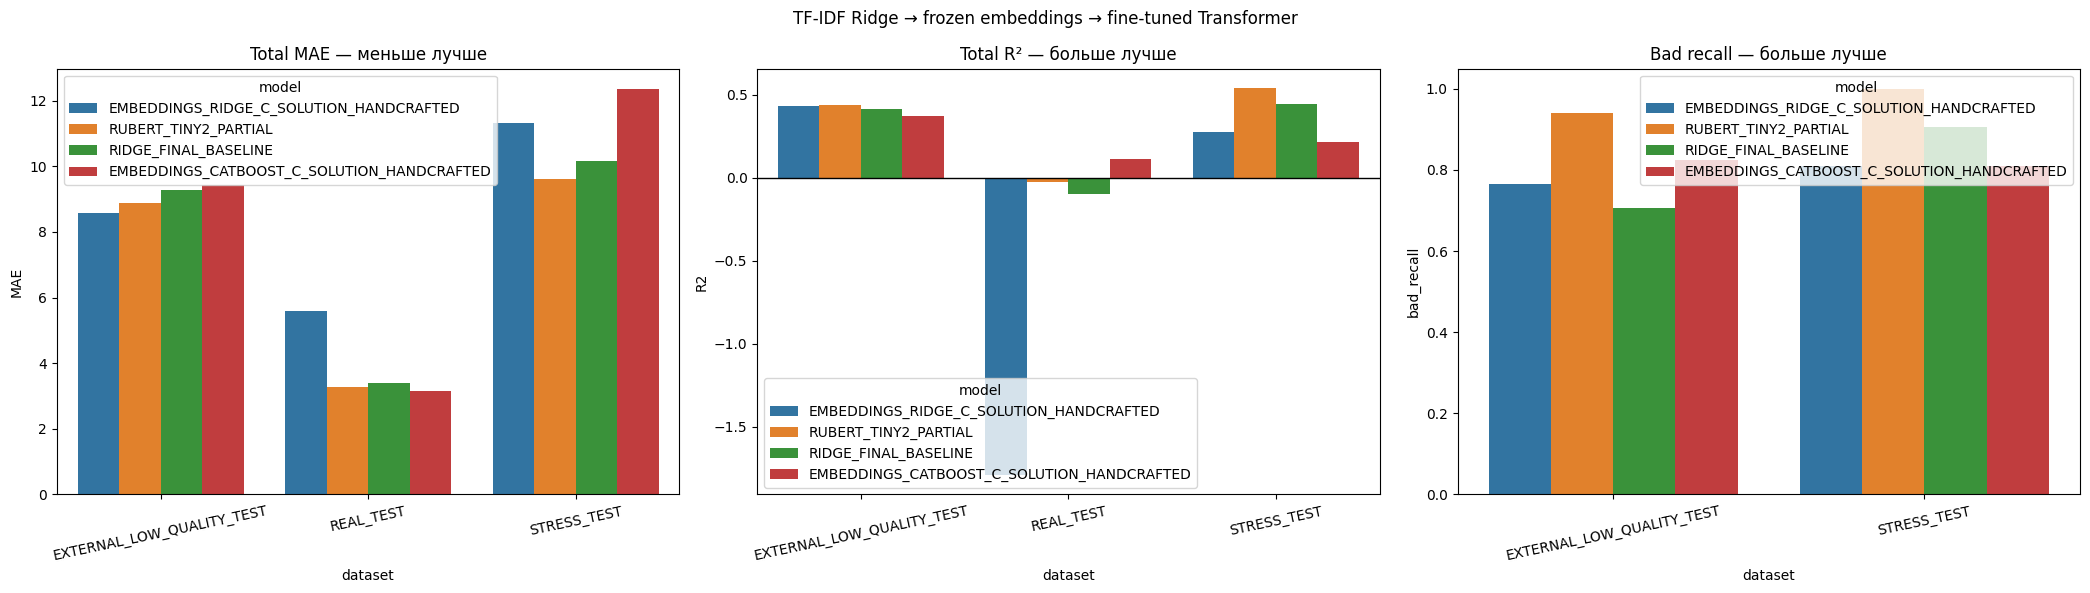

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
sns.barplot(data=transformer_total_comparison_df, x='dataset', y='MAE', hue='model', ax=axes[0])
axes[0].set_title('Total MAE - меньше лучше')
sns.barplot(data=transformer_total_comparison_df, x='dataset', y='R2', hue='model', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Total R² - больше лучше')
sns.barplot(data=transformer_total_comparison_df.dropna(subset=['bad_recall']), x='dataset', y='bad_recall', hue='model', ax=axes[2])
axes[2].set_ylim(0, 1.05)
axes[2].set_title('Bad recall - больше лучше')
for ax in axes:
    ax.tick_params(axis='x', rotation=12)
fig.suptitle('TF-IDF Ridge → frozen embeddings → fine-tuned Transformer')
fig.tight_layout()
fig.savefig(TRANSFORMER_DIR / 'model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

In [ ]:
transformer_total_comparison_df.to_csv(
    TRANSFORMER_DIR / 'model_comparison.csv', index=False
)


## Вывод

Лучшим оказался режим PARTIAL, в котором обучались выходной и последний transformer-слой.

- REAL_TEST: MAE 3,2893.
- STRESS_TEST: MAE 9,5991; все слабые решения распознаны.
- EXTERNAL_LOW_QUALITY_TEST: MAE 8,8913, R² 0,4416, bad recall 0,9412.

Частичная разморозка дала лучший баланс между точностью и устойчивостью на небольшом наборе данных.

RuBERT-tiny2 PARTIAL - пока основной кандидат для встраивания в проект
Лучший баланс real / low-quality, лучший stress, лучший bad recall и лучший external R²\
Однако для фактчекинга он всё равно не подойдет: без выхода в интернет реальность фактов нельзя определить